<h1>Non-negative least squares</h1>
<p><b>we fit a linear model with positive constraints on the regression coefficients and compare the estimated coefficients to a classic linear regression.</b></p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import r2_score

<b>Generate some random data</b>

In [2]:
np.random.seed(42)

n_samples, n_features = 200, 50
X = np.random.randn(n_samples, n_features)
true_coef = 3 * np.random.randn(n_features)
# Threshold coefficients to render them non-negative
true_coef[true_coef < 0] = 0
y = np.dot(X, true_coef)

# Add some noise
y += 5 * np.random.normal(size=(n_samples,))

<b>Split the data in train test split</b>

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

Fit the Non-Negative Least Sqaures

In [4]:
from sklearn.linear_model import LinearRegression

reg_nnls = LinearRegression(positive=True)
y_pred_nnls = reg_nnls.fit(X_train, y_train).predict(X_test)
r2_score_nnls = r2_score(y_test, y_pred_nnls)
print("NNLS R2 score", r2_score_nnls)

NNLS R2 score 0.8225220806196526


Fit an OLS.

In [5]:
reg_ols = LinearRegression()
y_pred_ols = reg_ols.fit(X_train, y_train).predict(X_test)
r2_score_ols = r2_score(y_test, y_pred_ols)
print("OLS R2 score", r2_score_ols)

OLS R2 score 0.743692629170035


Comparing the regression coefficients between OLS and NNLS, we can observe they are highly correlated (the dashed line is the identity relation), but the non-negative constraint shrinks some to 0. The Non-Negative Least squares inherently yield sparse results.

In [6]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

OLS coefficients [ 1.28168513 -1.28844518  0.20226258  0.02500373  4.92539674 -0.52479853
  2.4824517   0.95143469  1.0577752   2.50056662  2.58411112  1.96783647
 -0.47411806  0.41917169  2.94863573  0.4081959  -0.07420422  1.58777415
  0.03620705  5.44999794  5.11784678  1.92551583  3.88275153  0.31266597
  1.61481593  4.92665209  2.17729051  1.09759721 -1.11743953  0.44555934
  2.2388151   3.31316639  1.17471279 -0.16978928 -0.0133825   0.35957287
  0.51079989  0.38119072  1.03229206  8.14455627  0.02391242 -0.1007276
  0.34018775 -1.06953636  0.82579495  0.73183734  0.78080548  0.4480477
 -0.01091276  2.41262826]
NNLS coefficients [1.03686461 0.         0.         0.         4.67234641 0.
 2.62681264 0.38478851 0.69336723 2.32506932 2.92309675 1.83000387
 0.         0.39652115 2.49308667 0.45647139 0.         1.54785098
 0.07897252 5.24876537 5.18234002 1.91748832 3.75918102 0.46583565
 1.7968634  4.58607638 2.30242438 0.74725317 0.         0.55826588
 2.30791404 3.44282657 1.50652

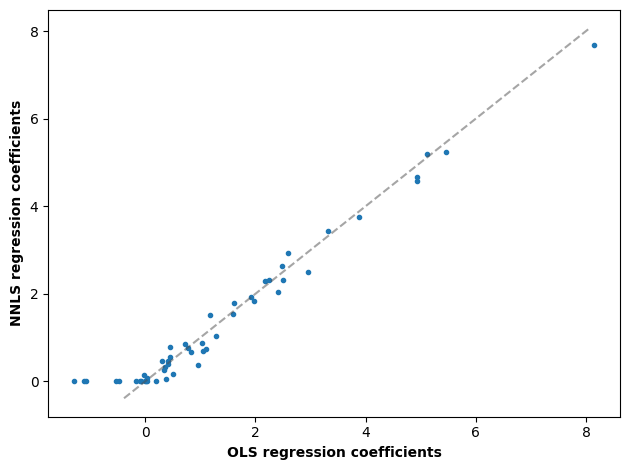

In [8]:
fig, ax = plt.subplots()
ax.plot(reg_ols.coef_, reg_nnls.coef_, linewidth=0, marker=".")

low_x, high_x = ax.get_xlim()
low_y, high_y = ax.get_ylim()
low = max(low_x, low_y)
high = min(high_x, high_y)
ax.plot([low, high], [low, high], ls="--", c=".3", alpha=0.5)
ax.set_xlabel("OLS regression coefficients", fontweight="bold")
ax.set_ylabel("NNLS regression coefficients", fontweight="bold")
save_fig("ols_vs_nnls_coefficients_plot")
print("OLS coefficients", reg_ols.coef_)
print("NNLS coefficients", reg_nnls.coef_)
plt.show()